# Análisis Exploratorio de Datos (EDA)
## Temperatura Global de la Superficie Terrestre
### Berkeley Earth — High Resolution Global Temperature Dataset

---

## Contexto científico

### ¿Qué mide este dataset?

Este archivo contiene la **anomalía de temperatura promedio global de la superficie terrestre**,
estimada combinando dos componentes:

| Componente | Fuente | Descripción |
|------------|--------|-------------|
| **Tierra** | Berkeley Earth (GHCN-Monthly v4, READER/BAS) | Temperatura del aire en superficie |
| **Océano** | HadSST4 (Kennedy et al. 2019) | Temperatura superficial del agua del mar (SST) |
| **Hielo marino** | HadISST2 (Titchner & Rayner 2014) | Concentración mensual de hielo por celda 1°×1° |

### ¿Cómo se construyó?

**1. Componente terrestre — Berkeley Earth**  
Combina 50 498 series de tiempo con más de 21 millones de datos mensuales de estaciones
meteorológicas en tierra. Usa un algoritmo de interpolación de alta resolución (0.25°×0.25°)
entrenado con ERA5 (Copernicus/ECMWF). El análisis terrestre fue ejecutado el 06-Mar-2023.

**2. Componente oceánica — HadSST4**  
Basado en ~457 millones de observaciones instantáneas de temperatura del agua.
Las SST son similares a la temperatura del aire cerca de la superficie, excepto en
zonas con hielo marino.

**3. Hielo marino — HadISST2 (Titchner & Rayner, 2014)**  
El papel del hielo marino es crítico para la fusión de los dos componentes:
- **Con hielo presente**: la anomalía se *extrapola* desde las temperaturas terrestres
  cercanas (el aire sobre el hielo difiere mucho de la temperatura del agua debajo).
- **Sin hielo**: se usa directamente la temperatura oceánica (HadSST4).
- En un mes típico, entre **3.5 % y 5.5 %** de la superficie terrestre está cubierta por hielo.
- HadISST2 provee la fracción de cobertura de hielo mes a mes con resolución 1°×1°,
  cubriendo desde 1850 hasta el presente.
- Antes de la era satelital (pre-1979) usa registros históricos de barcos, aviones y
  cartas náuticas digitalizadas. Desde 1979 incorpora datos del sensor SMMR/SSM/I (NSIDC).

**4. Anomalías y temperatura de referencia**  
Todos los valores se expresan como **anomalías en °C** respecto al promedio del período
**enero 1951 – diciembre 1980** (período de referencia estándar del WMO):

$$\text{Anomalía}(t) = T(t) - \overline{T}_{1951-1980}$$

La temperatura media global de referencia estimada es **14.148 ± 0.019 °C**.

**5. Incertidumbre**  
Las incertidumbres representan el **intervalo de confianza del 95 %** e incluyen:
- Efectos estadísticos del muestreo espacial insuficiente
- Sesgos instrumentales oceánicos (corrección de cubos vs. admisiones de motor)
- Subcobertura de la red de estaciones terrestres en el pasado

**6. Medias móviles centradas**  
El dataset incluye promedios móviles de 12 meses, 5, 10 y 20 años,
**centrados** en el punto reportado. Por ejemplo, el promedio anual
de enero–diciembre 1950 se reporta en **junio 1950**.
Esto explica los `NaN` en los extremos del dataset: se necesitan datos
futuros/pasados alrededor del punto central.

---

### Temperatura absoluta mensual de referencia (1951–1980)

| Ene | Feb | Mar | Abr | May | Jun | Jul | Ago | Sep | Oct | Nov | Dic |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| 12.31 | 12.52 | 13.15 | 14.07 | 15.01 | 15.68 | 15.91 | 15.72 | 15.17 | 14.30 | 13.33 | 12.59 |

> La Tierra no es simétrica respecto al ecuador: el hemisferio norte tiene más masa continental
> y el hemisferio sur más océano. Esto genera una **estacionalidad natural** en la temperatura
> global: el planeta es ligeramente más cálido en julio (verano boreal) que en enero.

---

**Referencias principales:**
- Titchner, H. A. & Rayner, N. A. (2014). HadISST2. *J. Geophys. Res. Atmos.*, 119. https://doi.org/10.1002/2013JD020316  
- Kennedy et al. (2019). HadSST4. *J. Geophys. Res. Atmos.* https://doi.org/10.1029/2018JD029867  
- Menne et al. (2018). GHCN-Monthly v4. *J. Climate.* https://doi.org/10.1175/JCLI-D-18-0094.1  
- Hersbach et al. (2018). ERA5. Copernicus CDS. http://doi.org/10.24381/cds.adbb2d47

## 0. Importación de librerías

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficas
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# Temperatura absoluta mensual de referencia (1951-1980)
TEMP_ABS_REF = {
    1: 12.31, 2: 12.52, 3: 13.15, 4: 14.07,
    5: 15.01, 6: 15.68, 7: 15.91, 8: 15.72,
    9: 15.17, 10: 14.30, 11: 13.33, 12: 12.59
}
MEDIA_GLOBAL_REF = 14.148  # °C

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 1. Carga de Datos

Usamos `pandas.read_csv()` para cargar el archivo. Inspeccionamos la estructura inicial del DataFrame.

In [50]:
df_raw = pd.read_csv('data/Global Temperatures.csv')

In [51]:
print('Columnas:')
print(df_raw.columns.tolist())

Columnas:
[' Year', ' Month', ' Month Anomaly', ' Month Unc.', '  Annual Anomaly', ' Annual Unc.', 'Five-year Anomaly', ' Five-year Unc.', '  Ten-year Anomaly', '  Ten-year Unc.', ' Twenty-year Anomaly', '  Twenty-year Unc.']


In [57]:
df_raw.columns

Index([' Year', ' Month', ' Month Anomaly', ' Month Unc.', '  Annual Anomaly',
       ' Annual Unc.', 'Five-year Anomaly', ' Five-year Unc.',
       '  Ten-year Anomaly', '  Ten-year Unc.', ' Twenty-year Anomaly',
       '  Twenty-year Unc.'],
      dtype='str')

In [58]:
# Los nombres de columnas tienen espacios al inicio/final (ej. ' Year', '  Annual Anomaly').
# Los eliminamos desde el principio para poder referenciar columnas sin espacios.
df_raw.columns = df_raw.columns.map(lambda name: name.strip())

print('\nColumnas después del strip:')
print(df_raw.columns.tolist())

print(f'\nFilas: {df_raw.shape[0]}  |  Columnas: {df_raw.shape[1]}')
df_raw.head(10)


Columnas después del strip:
['Year', 'Month', 'Month Anomaly', 'Month Unc.', 'Annual Anomaly', 'Annual Unc.', 'Five-year Anomaly', 'Five-year Unc.', 'Ten-year Anomaly', 'Ten-year Unc.', 'Twenty-year Anomaly', 'Twenty-year Unc.']

Filas: 2077  |  Columnas: 12


,Year,Month,Month Anomaly,Month Unc.,Annual Anomaly,Annual Unc.,Five-year Anomaly,Five-year Unc.,Ten-year Anomaly,Ten-year Unc.,Twenty-year Anomaly,Twenty-year Unc.
0,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.102,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.119,0.819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850,4,-0.485,0.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850,5,-0.351,0.549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1850,6,-0.528,0.448,-0.326,0.189,NaN,NaN,NaN,NaN,NaN,NaN
6,1850,7,0.036,0.457,-0.27,0.186,NaN,NaN,NaN,NaN,NaN,NaN
7,1850,8,-0.276,0.369,-0.283,0.143,NaN,NaN,NaN,NaN,NaN,NaN
8,1850,9,-0.328,0.33,-0.301,0.155,NaN,NaN,NaN,NaN,NaN,NaN
9,1850,10,-0.325,0.623,-0.296,0.148,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df_raw.tail(5)

,Year,Month,Month Anomaly,Month Unc.,Annual Anomaly,Annual Unc.,Five-year Anomaly,Five-year Unc.,Ten-year Anomaly,Ten-year Unc.,Twenty-year Anomaly,Twenty-year Unc.
2072,2022,9,0.971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2073,2022,10,1.126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2074,2022,11,0.626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075,2022,12,0.923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2076,2023,1,0.963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploración Inicial

### 2.1 Tipos de datos e información general

In [60]:
df_raw.shape

(2077, 12)

In [61]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2077 entries, 0 to 2076
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 2077 non-null   int64  
 1   Month                2077 non-null   int64  
 2   Month Anomaly        2077 non-null   float64
 3   Month Unc.           2077 non-null   str    
 4   Annual Anomaly       2077 non-null   str    
 5   Annual Unc.          2077 non-null   str    
 6   Five-year Anomaly    2077 non-null   str    
 7   Five-year Unc.       2077 non-null   str    
 8   Ten-year Anomaly     2077 non-null   str    
 9   Ten-year Unc.        2077 non-null   str    
 10  Twenty-year Anomaly  2077 non-null   str    
 11  Twenty-year Unc.     2077 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 194.8 KB


### 2.2 Estadísticas descriptivas con `describe()`

`describe()` nos da un resumen estadístico: conteo, media, desviación estándar, mínimo, cuartiles y máximo.

In [62]:
df_raw.describe().round(4)

,Year,Month,Month Anomaly
count,2077.0000,2077.0000,2077.0000
mean,1936.0419,6.4974,0.0396
std,49.9764,3.4542,0.4187
min,1850.0000,1.0000,-0.9700
25%,1893.0000,3.0000,-0.2530
50%,1936.0000,6.0000,-0.0390
75%,1979.0000,9.0000,0.2520
max,2023.0000,12.0000,1.4990


### 2.3 Detección de Valores Faltantes

Antes de hacer cualquier análisis de nulos, hay que entender un **problema de parsing**
que tiene este CSV: varias columnas llegan como `str` en lugar de `float`.

In [63]:
# Paso 1 — ¿Qué tipos de datos leyó pandas?
print('Dtypes del CSV recién cargado:')
print(df_raw.dtypes)
print()

# Columnas que deberían ser float pero llegaron como str
cols_str = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Columnas leídas como str ({len(cols_str)}): {cols_str}')

Dtypes del CSV recién cargado:
Year                     int64
Month                    int64
Month Anomaly          float64
Month Unc.                 str
Annual Anomaly             str
Annual Unc.                str
Five-year Anomaly          str
Five-year Unc.             str
Ten-year Anomaly           str
Ten-year Unc.              str
Twenty-year Anomaly        str
Twenty-year Unc.           str
dtype: object

Columnas leídas como str (9): ['Month Unc.', 'Annual Anomaly', 'Annual Unc.', 'Five-year Anomaly', 'Five-year Unc.', 'Ten-year Anomaly', 'Ten-year Unc.', 'Twenty-year Anomaly', 'Twenty-year Unc.']


In [64]:
# Paso 2 — Ver los valores crudos de una columna str
# Los NaN aparecen como cadenas con espacios: '      NaN', '  NaN', etc.
print('Valores crudos en Annual Anomaly (primeros 8):')
print(repr(df_raw['Annual Anomaly'].head(8).tolist()))
print()
print('Valores crudos en Five-year Anomaly (primeros 8):')
print(repr(df_raw['Five-year Anomaly'].head(8).tolist()))
print()
# Por eso isnull() devuelve False: son strings, no np.nan
print('isnull() en Annual Anomaly (primeros 8) → todo False porque son strings:')
print(df_raw['Annual Anomaly'].head(8).isnull().tolist())

Valores crudos en Annual Anomaly (primeros 8):
['      NaN', '      NaN', '      NaN', '      NaN', '      NaN', '-0.326', '-0.27', '-0.283']

Valores crudos en Five-year Anomaly (primeros 8):
['   NaN', '   NaN', '   NaN', '   NaN', '   NaN', '   NaN', '   NaN', '   NaN']

isnull() en Annual Anomaly (primeros 8) → todo False porque son strings:
[False, False, False, False, False, False, False, False]


In [65]:
# Paso 3 — Conteo de nulos ANTES del fix: reporta 0 en todas las columnas str
nulos_raw = df_raw.isnull().sum()
pd.DataFrame({
    'dtype': df_raw.dtypes,
    'nulos reportados': nulos_raw,
})

,dtype,nulos reportados
Year,int64,0
Month,int64,0
Month Anomaly,float64,0
Month Unc.,str,0
Annual Anomaly,str,0
Annual Unc.,str,0
Five-year Anomaly,str,0
Five-year Unc.,str,0
Ten-year Anomaly,str,0
Ten-year Unc.,str,0


---
## 3. Limpieza y Preprocesamiento

### 3.1 Normalización de nombres de columnas

Limpiamos los nombres de columnas: quitamos espacios extra y usamos nombres descriptivos en inglés técnico.

In [72]:
# Copiar el DataFrame original para no modificarlo
df = df_raw.copy()

# Paso 1: renombrar columnas a nombres descriptivos
# (los espacios ya fueron eliminados al cargar el CSV)
df = df.rename(columns={
    'Year':                 'year',
    'Month':                'month',
    'Month Anomaly':        'anomaly_monthly',
    'Month Unc.':           'unc_monthly',
    'Annual Anomaly':       'anomaly_annual',
    'Annual Unc.':          'unc_annual',
    'Five-year Anomaly':    'anomaly_5yr',
    'Five-year Unc.':       'unc_5yr',
    'Ten-year Anomaly':     'anomaly_10yr',
    'Ten-year Unc.':        'unc_10yr',
    'Twenty-year Anomaly':  'anomaly_20yr',
    'Twenty-year Unc.':     'unc_20yr'
})

# Paso 2: convertir columnas str a float.
# El CSV almacena los NaN como '      NaN' (string con espacios).
# str.strip() quita los espacios → 'NaN'; pd.to_numeric(..., errors='coerce')
# convierte 'NaN' a np.nan y cualquier número válido a float.
cols_str = df.select_dtypes(include='object').columns
for col in cols_str:
    df[col] = pd.to_numeric(df[col].str.strip(), errors='coerce')

print('Columnas y tipos DESPUÉS de la limpieza:')
print(df.dtypes)
df.head(3)

Columnas y tipos DESPUÉS de la limpieza:
year                 int64
month                int64
anomaly_monthly    float64
unc_monthly        float64
anomaly_annual     float64
unc_annual         float64
anomaly_5yr        float64
unc_5yr            float64
anomaly_10yr       float64
unc_10yr           float64
anomaly_20yr       float64
unc_20yr           float64
dtype: object


,year,month,anomaly_monthly,unc_monthly,anomaly_annual,unc_annual,anomaly_5yr,unc_5yr,anomaly_10yr,unc_10yr,anomaly_20yr,unc_20yr
0,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.102,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.119,0.819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ahora que las columnas son `float64`, `isnull()` detecta correctamente los NaN.
Los NaN en las medias móviles son **esperados**: se necesitan datos antes/después del punto
central para calcular el promedio, por eso faltan valores al inicio y al final del período.

In [73]:
# Conteo de nulos DESPUÉS de la limpieza (valores reales)
nulos_real = df.isnull().sum()
pct_real = (nulos_real / len(df) * 100).round(2)

resumen_real = pd.DataFrame({
    'Nulos reales': nulos_real,
    '% del total': pct_real,
    'dtype': df.dtypes
})
print('Valores faltantes por columna (DESPUÉS de limpiar):')
resumen_real

Valores faltantes por columna (DESPUÉS de limpiar):


,Nulos reales,% del total,dtype
year,0,0.00,int64
month,0,0.00,int64
anomaly_monthly,0,0.00,float64
unc_monthly,13,0.63,float64
anomaly_annual,11,0.53,float64
unc_annual,24,1.16,float64
anomaly_5yr,59,2.84,float64
unc_5yr,72,3.47,float64
anomaly_10yr,119,5.73,float64
unc_10yr,132,6.36,float64


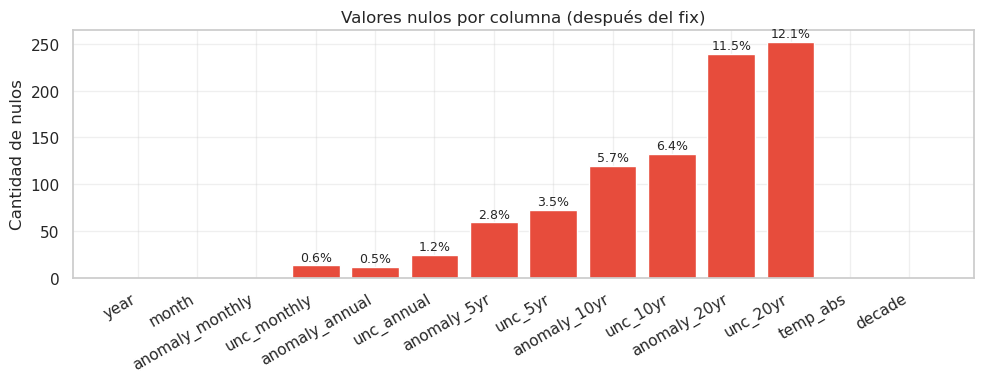

In [45]:
# Gráfico de barras: nulos reales por columna
nulos_plot = df.isnull().sum()
pct_plot = (nulos_plot / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(nulos_plot.index, nulos_plot.values,
              color=['#e74c3c' if v > 0 else '#2ecc71' for v in nulos_plot.values])

# Etiqueta con el porcentaje encima de cada barra
for bar, pct in zip(bars, pct_plot.values):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f'{pct}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Valores nulos por columna (después del fix)')
ax.set_ylabel('Cantidad de nulos')
ax.set_xticklabels(nulos_plot.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Creación de columna de fecha

Combinamos `year` y `month` en una columna `date` de tipo `datetime64`. Esto es fundamental para trabajar con series de tiempo.

In [78]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# Poner la fecha como primer índice (pero mantenerla como columna también)
df = df.set_index('date').sort_index()

print(f'Período: {df.index.min().date()} → {df.index.max().date()}')
print(f'Total de meses: {len(df)}')
df.head(3)

Período: 1850-01-01 → 2023-01-01
Total de meses: 2077


,year,month,anomaly_monthly,unc_monthly,anomaly_annual,unc_annual,anomaly_5yr,unc_5yr,anomaly_10yr,unc_10yr,anomaly_20yr,unc_20yr
date,,,,,,,,,,,,
1850-01-01,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1850-02-01,1850,2,-0.102,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1850-03-01,1850,3,-0.119,0.819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3 Temperatura absoluta mensual

Como los datos son **anomalías** respecto al período 1951–1980, podemos reconstruir la **temperatura absoluta estimada** sumando la anomalía a la temperatura de referencia de ese mes.

In [80]:
 df['month'].map(TEMP_ABS_REF)

date
1850-01-01    12.31
1850-02-01    12.52
1850-03-01    13.15
1850-04-01    14.07
1850-05-01    15.01
              ...  
2022-09-01    15.17
2022-10-01    14.30
2022-11-01    13.33
2022-12-01    12.59
2023-01-01    12.31
Name: month, Length: 2077, dtype: float64

In [82]:
# Temperatura absoluta = temperatura de referencia del mes + anomalía
df['temp_abs'] = df['month'].map(TEMP_ABS_REF) + df['anomaly_monthly']

print('Temperatura absoluta estimada (primeras filas):')
df[['year', 'month', 'anomaly_monthly', 'temp_abs']].head(13)

Temperatura absoluta estimada (primeras filas):


,year,month,anomaly_monthly,temp_abs
date,,,,
1850-01-01,1850,1,-0.801,11.509
1850-02-01,1850,2,-0.102,12.418
1850-03-01,1850,3,-0.119,13.031
1850-04-01,1850,4,-0.485,13.585
1850-05-01,1850,5,-0.351,14.659
1850-06-01,1850,6,-0.528,15.152
1850-07-01,1850,7,0.036,15.946
1850-08-01,1850,8,-0.276,15.444
1850-09-01,1850,9,-0.328,14.842


---
## 4. Análisis Estadístico Descriptivo con NumPy

### 4.1 Estadísticos sobre la anomalía mensual

In [83]:
anomalia = df['anomaly_monthly'].dropna().values

stats = {
    'N':               len(anomalia),
    'Media':           np.mean(anomalia),
    'Mediana':         np.median(anomalia),
    'Desv. Estándar':  np.std(anomalia),
    'Varianza':        np.var(anomalia),
    'Mínimo':          np.min(anomalia),
    'Máximo':          np.max(anomalia),
    'Q1 (25%)':        np.percentile(anomalia, 25),
    'Q3 (75%)':        np.percentile(anomalia, 75),
    'IQR':             np.percentile(anomalia, 75) - np.percentile(anomalia, 25),
    'Asimetría':       float(pd.Series(anomalia).skew()),
    'Curtosis':        float(pd.Series(anomalia).kurt())
}

for k, v in stats.items():
    print(f'  {k:<22}: {v:.4f}' if isinstance(v, float) else f'  {k:<22}: {v}')

  N                     : 2077
  Media                 : 0.0396
  Mediana               : -0.0390
  Desv. Estándar        : 0.4186
  Varianza              : 0.1752
  Mínimo                : -0.9700
  Máximo                : 1.4990
  Q1 (25%)              : -0.2530
  Q3 (75%)              : 0.2520
  IQR                   : 0.5050
  Asimetría             : 0.7390
  Curtosis              : 0.1850


### 4.2 Análisis por décadas

Agrupamos los datos por década para ver cómo cambia la temperatura promedio a lo largo del tiempo.

In [86]:
df['decade'] = (df['year'] // 10) * 10

In [88]:
df['year'].unique()

array([1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860,
       1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871,
       1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882,
       1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893,
       1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904,
       1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915,
       1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926,
       1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937,
       1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948,
       1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 20

In [87]:
df['decade'].unique()

array([1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950,
       1960, 1970, 1980, 1990, 2000, 2010, 2020])

In [89]:
df['decade'] = (df['year'] // 10) * 10

stats_decada = df.groupby('decade')['anomaly_monthly'].agg(
    media='mean',
    mediana='median',
    desv_std='std',
    minimo='min',
    maximo='max',
    conteo='count'
).round(3)

print('Estadísticas de anomalía mensual por década (°C):')
stats_decada

Estadísticas de anomalía mensual por década (°C):


,media,mediana,desv_std,minimo,maximo,conteo
decade,,,,,,
1850,-0.207,-0.215,0.240,-0.801,0.676,120
1860,-0.234,-0.221,0.270,-0.970,0.319,120
1870,-0.147,-0.184,0.274,-0.843,1.037,120
1880,-0.290,-0.304,0.220,-0.767,0.418,120
1890,-0.252,-0.232,0.189,-0.869,0.128,120
1900,-0.318,-0.324,0.223,-0.863,0.228,120
1910,-0.300,-0.290,0.219,-0.760,0.253,120
1920,-0.162,-0.168,0.178,-0.669,0.403,120
1930,-0.036,-0.031,0.205,-0.456,0.662,120


---
## 5. Visualizaciones

### 5.1 Serie temporal de anomalías mensuales

Graficamos la anomalía mensual con su banda de incertidumbre (intervalo de confianza del 95%).

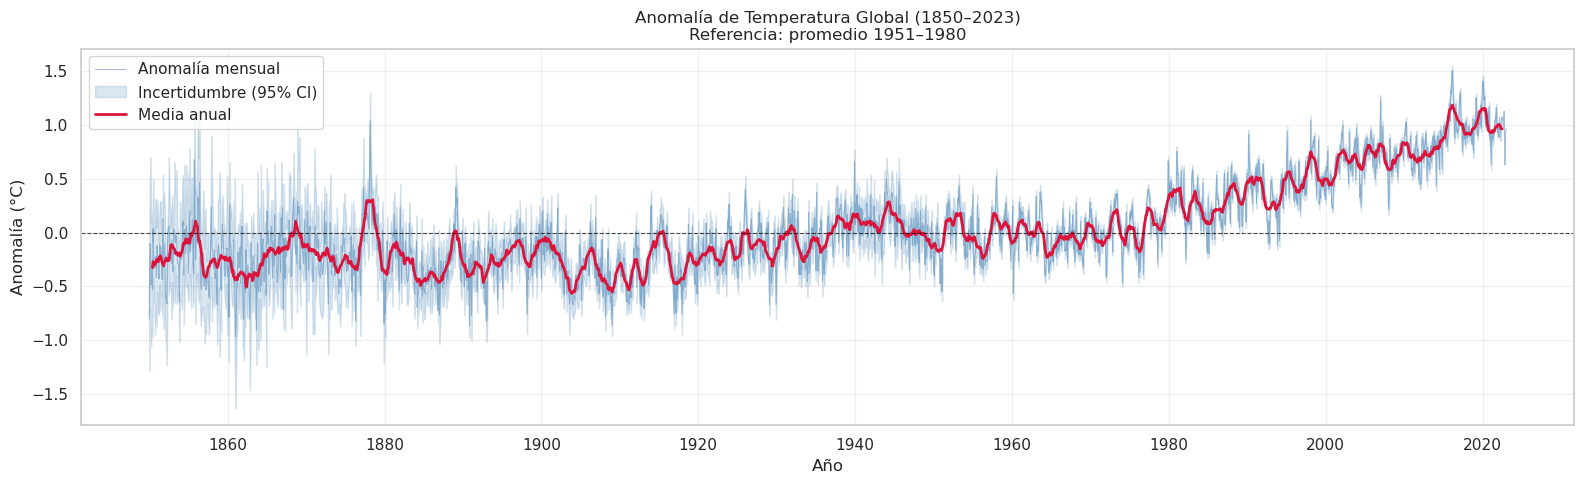

In [92]:
fig, ax = plt.subplots(figsize=(16, 5))

# Anomalía mensual
ax.plot(df.index, df['anomaly_monthly'],
        color='steelblue', alpha=0.5, linewidth=0.8, label='Anomalía mensual')

# Banda de incertidumbre
mask = df['unc_monthly'].notna()
ax.fill_between(
    df.index[mask],
    df['anomaly_monthly'][mask] - df['unc_monthly'][mask],
    df['anomaly_monthly'][mask] + df['unc_monthly'][mask],
    alpha=0.2, color='steelblue', label='Incertidumbre (95% CI)'
)

# Media móvil anual
ax.plot(df.index, df['anomaly_annual'],
        color='crimson', linewidth=2, label='Media anual')

# Línea de referencia en 0
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Anomalía de Temperatura Global (1850–2023)\nReferencia: promedio 1951–1980')
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía (°C)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 5.2 Medias móviles a diferentes escalas

Las medias móviles suavizan el ruido de corto plazo y revelan la tendencia de largo plazo.

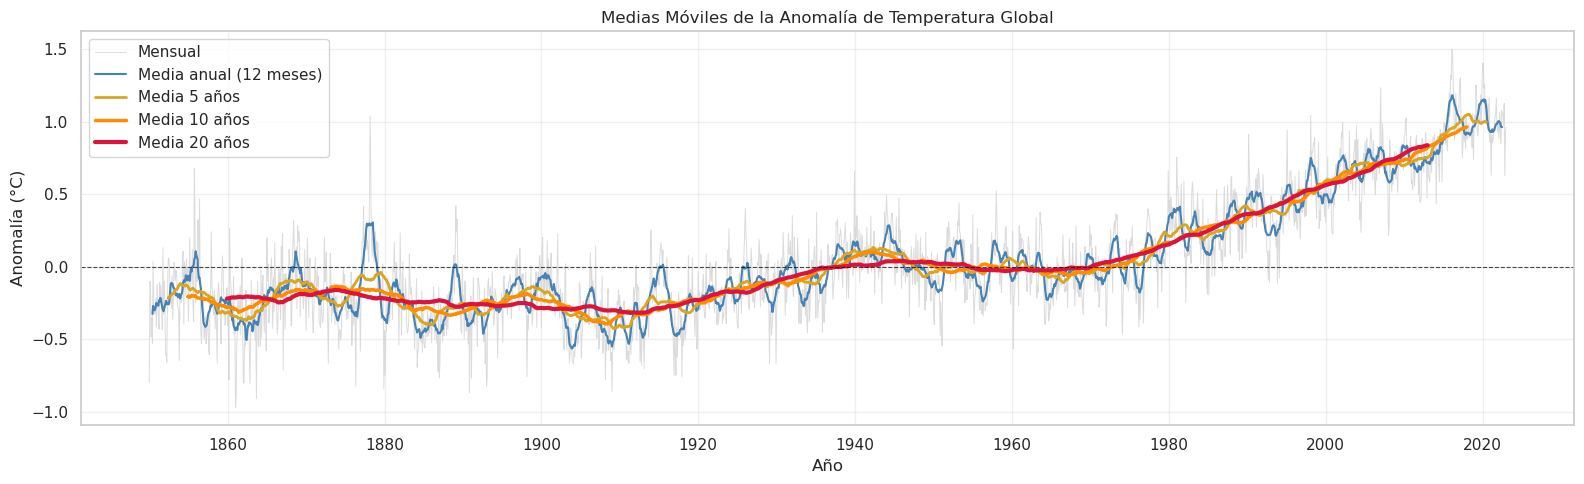

In [19]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['anomaly_monthly'],
        color='lightgray', linewidth=0.7, alpha=0.8, label='Mensual')
ax.plot(df.index, df['anomaly_annual'],
        color='steelblue', linewidth=1.5, label='Media anual (12 meses)')
ax.plot(df.index, df['anomaly_5yr'],
        color='goldenrod', linewidth=2, label='Media 5 años')
ax.plot(df.index, df['anomaly_10yr'],
        color='darkorange', linewidth=2.5, label='Media 10 años')
ax.plot(df.index, df['anomaly_20yr'],
        color='crimson', linewidth=3, label='Media 20 años')

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_title('Medias Móviles de la Anomalía de Temperatura Global')
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía (°C)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 5.3 Distribución de anomalías mensuales

El histograma muestra la frecuencia de cada rango de anomalía. La curva KDE (Kernel Density Estimate) es una estimación suavizada de la distribución de probabilidad.

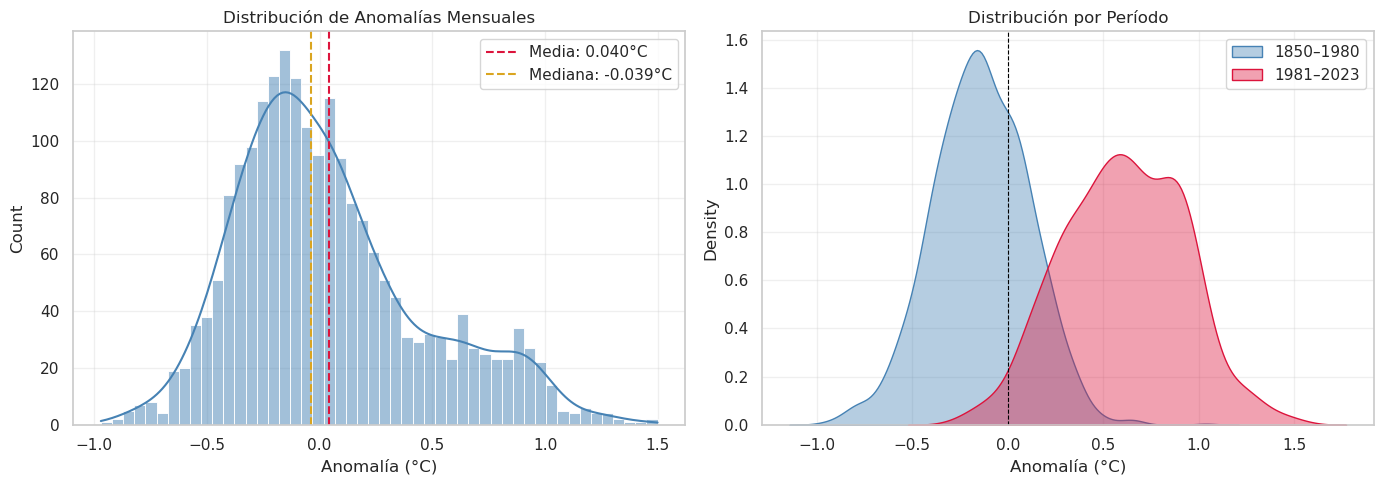

Media 1850–1980: -0.142°C  vs  Media 1981–2023: 0.606°C
Diferencia: 0.748°C


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE
sns.histplot(df['anomaly_monthly'].dropna(), bins=50,
             kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['anomaly_monthly'].mean(), color='crimson',
                linestyle='--', linewidth=1.5, label=f"Media: {df['anomaly_monthly'].mean():.3f}°C")
axes[0].axvline(df['anomaly_monthly'].median(), color='goldenrod',
                linestyle='--', linewidth=1.5, label=f"Mediana: {df['anomaly_monthly'].median():.3f}°C")
axes[0].set_title('Distribución de Anomalías Mensuales')
axes[0].set_xlabel('Anomalía (°C)')
axes[0].legend()

# Comparación por período (antes y después de 1980)
antes = df.loc[df['year'] <= 1980, 'anomaly_monthly'].dropna()
despues = df.loc[df['year'] > 1980, 'anomaly_monthly'].dropna()

sns.kdeplot(antes, ax=axes[1], label='1850–1980', fill=True, alpha=0.4, color='steelblue')
sns.kdeplot(despues, ax=axes[1], label='1981–2023', fill=True, alpha=0.4, color='crimson')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Distribución por Período')
axes[1].set_xlabel('Anomalía (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Media 1850–1980: {antes.mean():.3f}°C  vs  Media 1981–2023: {despues.mean():.3f}°C')
print(f'Diferencia: {despues.mean() - antes.mean():.3f}°C')

### 5.4 Estacionalidad: Boxplot por mes

Cada boxplot muestra la distribución de anomalías para ese mes a lo largo de todos los años. Si el dataset tuviera estacionalidad en las anomalías, la vería aquí.

In [101]:
for m in range(1, 13):
    print(df.loc[df['month'] == m, 'anomaly_monthly'].dropna().values)

[-8.010e-01 -1.220e-01 -2.900e-01 -3.660e-01 -2.200e-01 -3.770e-01
  2.500e-02 -4.940e-01 -1.470e-01 -2.950e-01 -4.070e-01 -9.700e-01
 -8.010e-01 -9.400e-02 -3.010e-01  1.970e-01  1.630e-01  2.290e-01
 -9.000e-03  1.710e-01 -4.410e-01 -2.600e-01 -3.010e-01 -2.590e-01
 -3.450e-01 -2.960e-01 -1.120e-01 -2.750e-01  3.300e-02  1.760e-01
 -4.340e-01 -3.650e-01  2.330e-01 -4.400e-01 -2.460e-01 -5.130e-01
 -5.230e-01 -7.670e-01 -1.950e-01  5.800e-02 -2.240e-01 -2.020e-01
 -1.070e-01 -8.240e-01 -3.540e-01 -3.460e-01 -5.400e-02 -8.300e-02
 -3.600e-02 -1.130e-01 -4.220e-01 -1.380e-01 -5.200e-02 -4.700e-02
 -6.600e-01 -2.600e-01 -2.550e-01 -4.200e-01 -4.210e-01 -8.630e-01
 -1.970e-01 -6.450e-01 -1.360e-01 -4.090e-01  2.530e-01 -1.270e-01
  6.400e-02 -3.030e-01 -4.030e-01 -1.550e-01 -3.400e-02  8.800e-02
 -2.450e-01 -1.410e-01 -7.400e-02 -4.170e-01  4.030e-01 -2.420e-01
  8.500e-02 -2.980e-01 -3.040e-01 -1.100e-02  3.520e-01 -2.610e-01
 -2.410e-01 -3.530e-01 -3.820e-01 -6.000e-03  2.220e-01  1.680

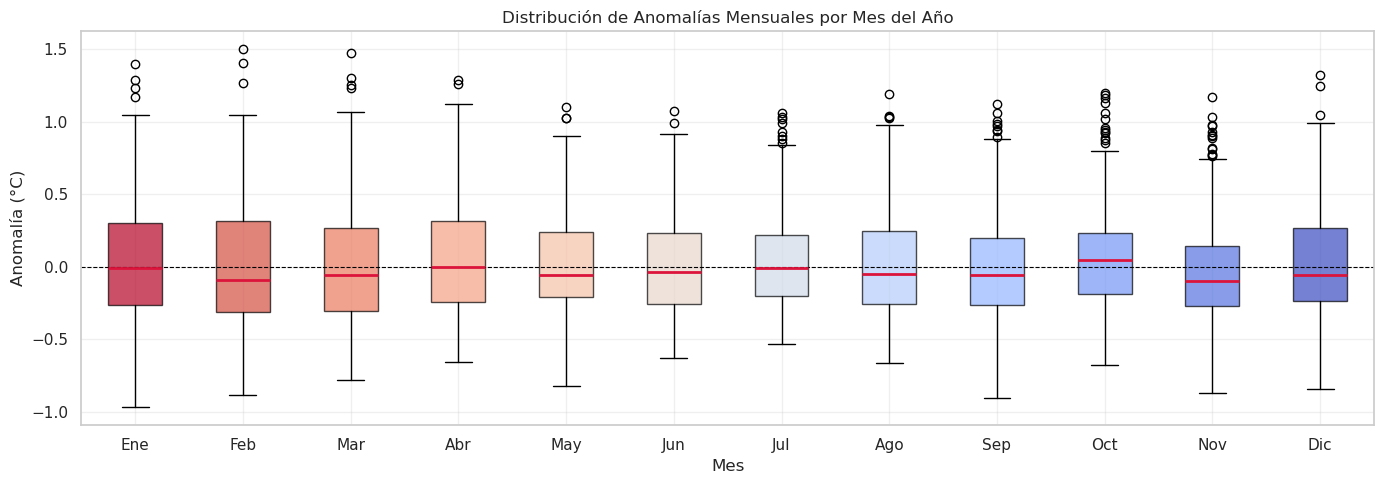

In [103]:
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(14, 5))

data_meses = [df.loc[df['month'] == m, 'anomaly_monthly'].dropna().values for m in range(1, 13)]

bp = ax.boxplot(data_meses, patch_artist=True, notch=False,
                medianprops={'color': 'crimson', 'linewidth': 2})

colors = plt.cm.coolwarm_r(np.linspace(0, 1, 12))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(MESES)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Distribución de Anomalías Mensuales por Mes del Año')
ax.set_xlabel('Mes')
ax.set_ylabel('Anomalía (°C)')
plt.tight_layout()
plt.show()

### 5.5 Heatmap: Anomalía por Año y Mes

Un heatmap 2D nos permite ver patrones de calentamiento simultáneamente en dos dimensiones: año y mes.

In [104]:
df.pivot_table(values='anomaly_monthly', index='year', columns='month')

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1850,-0.801,-0.102,-0.119,-0.485,-0.351,-0.528,0.036,-0.276,-0.328,-0.325,-0.219,-0.417
1851,-0.122,-0.265,-0.329,-0.431,-0.110,-0.216,-0.130,-0.247,-0.435,0.131,-0.327,-0.101
1852,-0.290,-0.606,-0.599,-0.659,-0.199,0.039,0.059,-0.016,-0.251,-0.170,-0.287,-0.063
1853,-0.366,-0.208,0.029,0.002,-0.096,-0.027,-0.041,-0.260,-0.287,-0.290,-0.647,-0.193
1854,-0.220,-0.248,-0.214,0.065,0.106,-0.396,0.034,-0.004,-0.196,0.056,-0.091,-0.015
...,...,...,...,...,...,...,...,...,...,...,...,...
2019,1.045,0.956,1.252,1.124,0.901,0.912,1.015,1.022,1.005,1.184,0.975,1.244
2020,1.398,1.406,1.230,1.259,1.028,0.990,1.033,0.979,1.121,0.942,1.168,0.859
2021,0.919,0.630,0.910,0.853,0.872,0.907,0.989,1.030,1.062,1.160,0.967,0.927


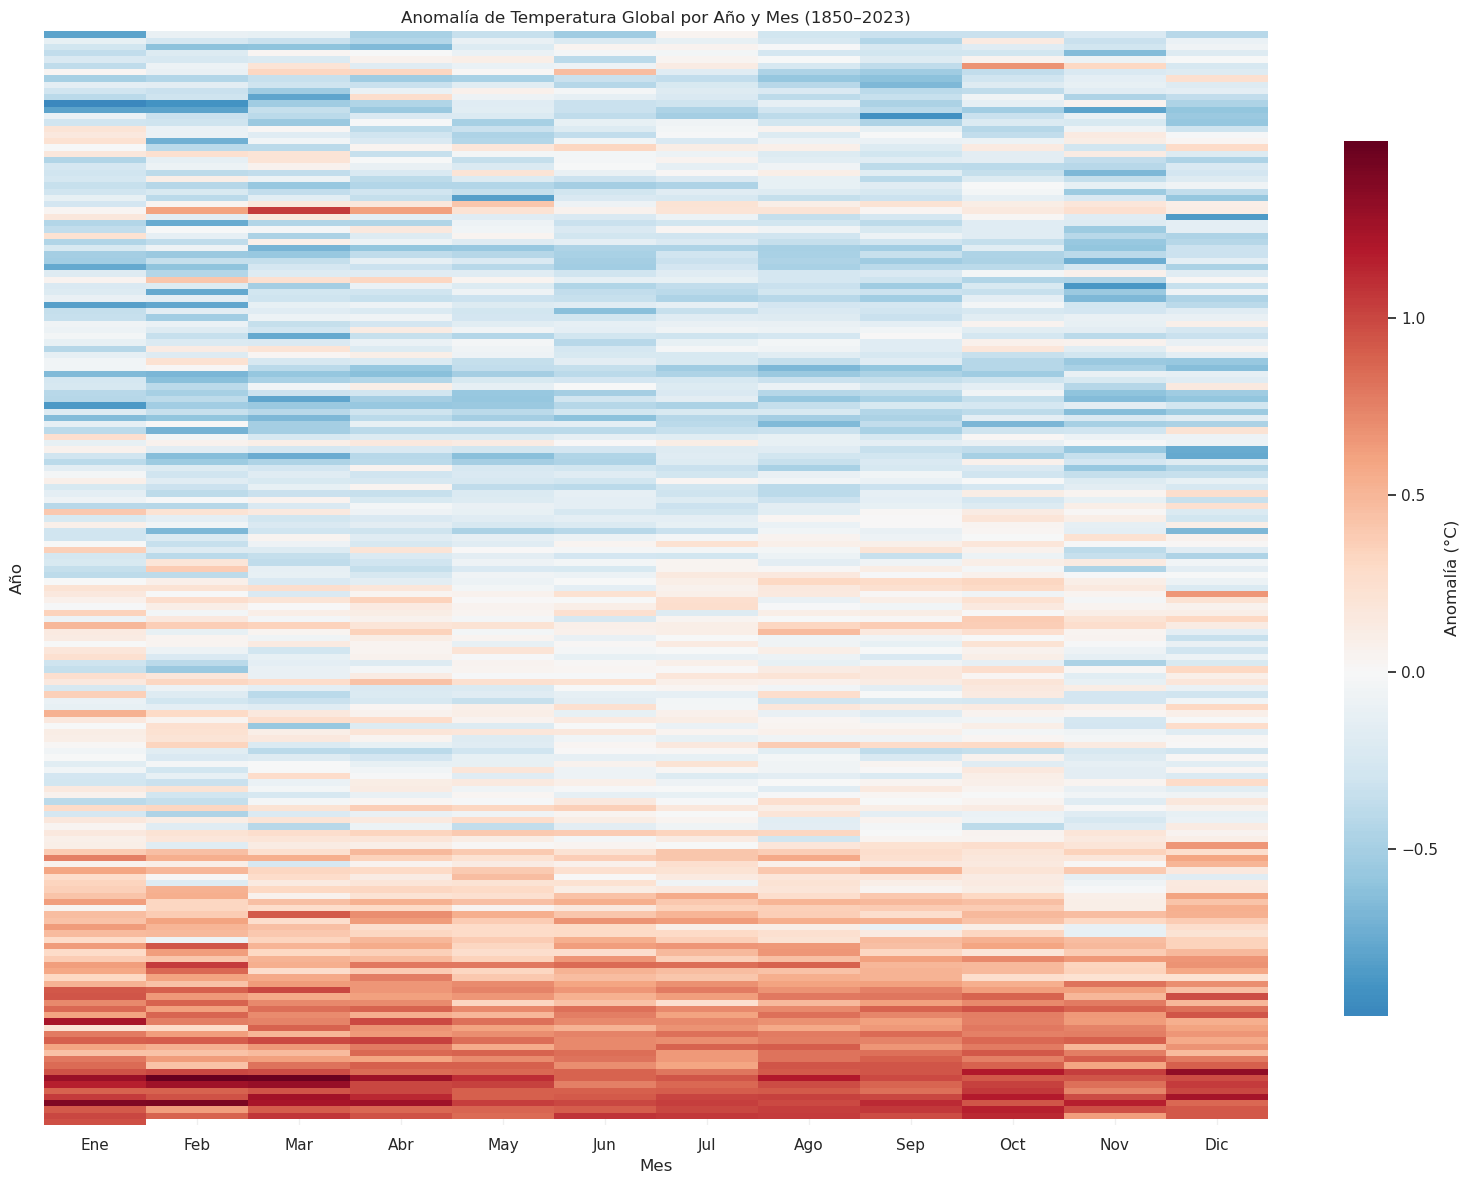

In [22]:
# Tabla pivote: filas = año, columnas = mes
pivot = df.pivot_table(values='anomaly_monthly', index='year', columns='month')
pivot.columns = MESES

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    pivot, cmap='RdBu_r', center=0,
    linewidths=0,
    cbar_kws={'label': 'Anomalía (°C)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Anomalía de Temperatura Global por Año y Mes (1850–2023)')
ax.set_xlabel('Mes')
ax.set_ylabel('Año')
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

### 5.6 Anomalía promedio por década (barras)

Visualizamos la tendencia de calentamiento década a década.

In [113]:
df.groupby('decade')['anomaly_monthly'].mean()

decade
1850   -0.206908
1860   -0.233700
1870   -0.147367
1880   -0.289708
1890   -0.251733
1900   -0.318250
1910   -0.299825
1920   -0.161733
1930   -0.036117
1940    0.064750
1950   -0.009592
1960   -0.040108
1970    0.032425
1980    0.272192
1990    0.450917
2000    0.670258
2010    0.880775
2020    1.004649
Name: anomaly_monthly, dtype: float64

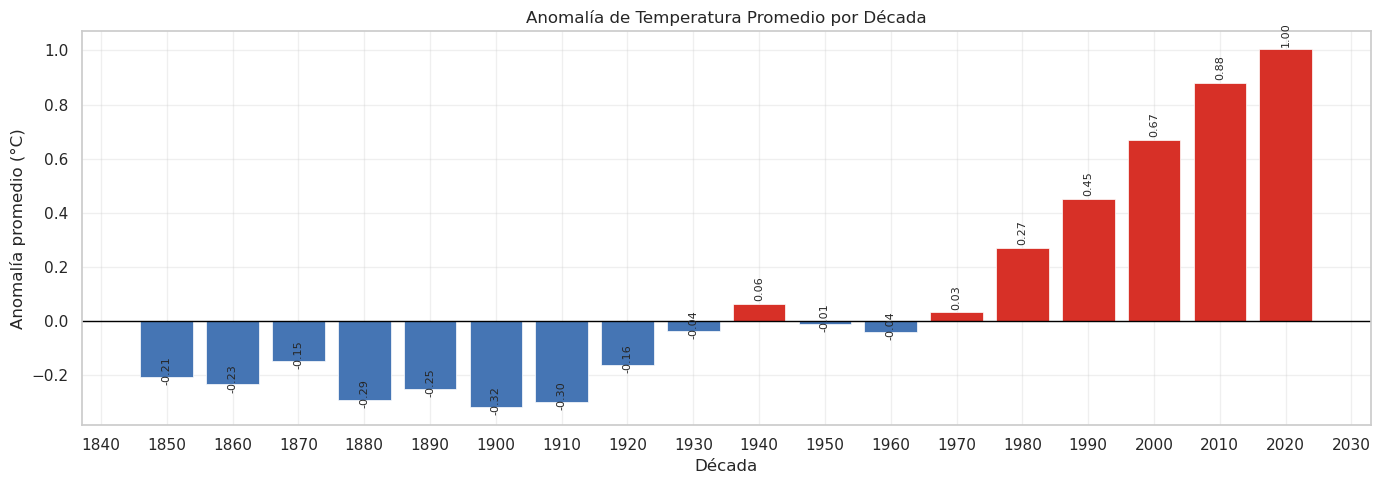

In [116]:
media_decada = df.groupby('decade')['anomaly_monthly'].mean()

colors_bar = ['#d73027' if v > 0 else '#4575b4' for v in media_decada.values]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(media_decada.index, media_decada.values,
              color=colors_bar, edgecolor='white', linewidth=0.5, width=8)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Anomalía de Temperatura Promedio por Década')
ax.set_xlabel('Década')
ax.set_ylabel('Anomalía promedio (°C)')
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))

for bar, val in zip(bars, media_decada.values):
    offset = 0.01 if val >= 0 else -0.03
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

### 5.7 Detección de Outliers con el método IQR

Identificamos valores atípicos usando el rango intercuartílico (IQR). Un outlier es cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

In [24]:
serie = df['anomaly_monthly'].dropna()
Q1 = serie.quantile(0.25)
Q3 = serie.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df.loc[(df['anomaly_monthly'] < lim_inf) | (df['anomaly_monthly'] > lim_sup)]

print(f'Q1={Q1:.3f}  Q3={Q3:.3f}  IQR={IQR:.3f}')
print(f'Límite inferior: {lim_inf:.3f}  |  Límite superior: {lim_sup:.3f}')
print(f'\nOutliers detectados: {len(outliers)}')
outliers[['year', 'month', 'anomaly_monthly']].head(20)

Q1=-0.253  Q3=0.252  IQR=0.505
Límite inferior: -1.010  |  Límite superior: 1.010

Outliers detectados: 43


,year,month,anomaly_monthly
date,,,
1878-03-01,1878,3,1.037
1998-02-01,1998,2,1.043
2007-01-01,2007,1,1.234
2010-04-01,2010,4,1.026
2015-10-01,2015,10,1.197
2015-11-01,2015,11,1.035
2015-12-01,2015,12,1.320
2016-01-01,2016,1,1.289
2016-02-01,2016,2,1.499


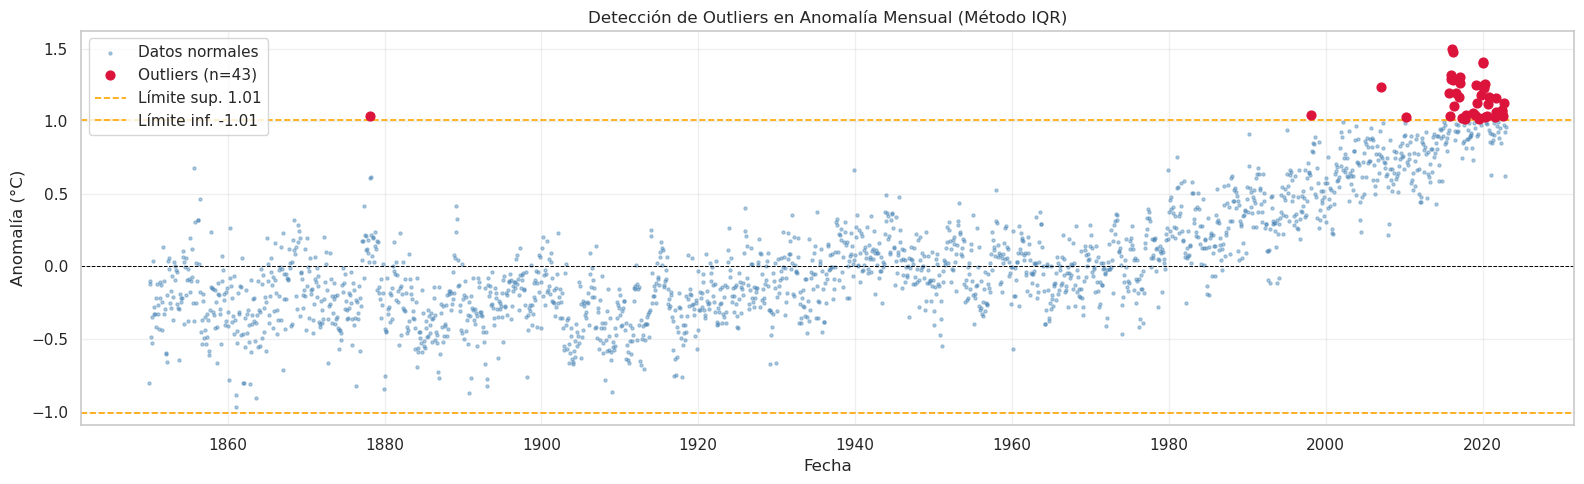

In [25]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.scatter(df.index, df['anomaly_monthly'],
           s=5, color='steelblue', alpha=0.4, label='Datos normales')
ax.scatter(outliers.index, outliers['anomaly_monthly'],
           s=40, color='crimson', zorder=5, label=f'Outliers (n={len(outliers)})')

ax.axhline(lim_sup, color='orange', linestyle='--', linewidth=1.2, label=f'Límite sup. {lim_sup:.2f}')
ax.axhline(lim_inf, color='orange', linestyle='--', linewidth=1.2, label=f'Límite inf. {lim_inf:.2f}')
ax.axhline(0, color='black', linestyle='--', linewidth=0.7)

ax.set_title('Detección de Outliers en Anomalía Mensual (Método IQR)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Anomalía (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.8 Temperatura absoluta estimada

Reconstruimos la temperatura real sumando la anomalía a la temperatura de referencia mensual.

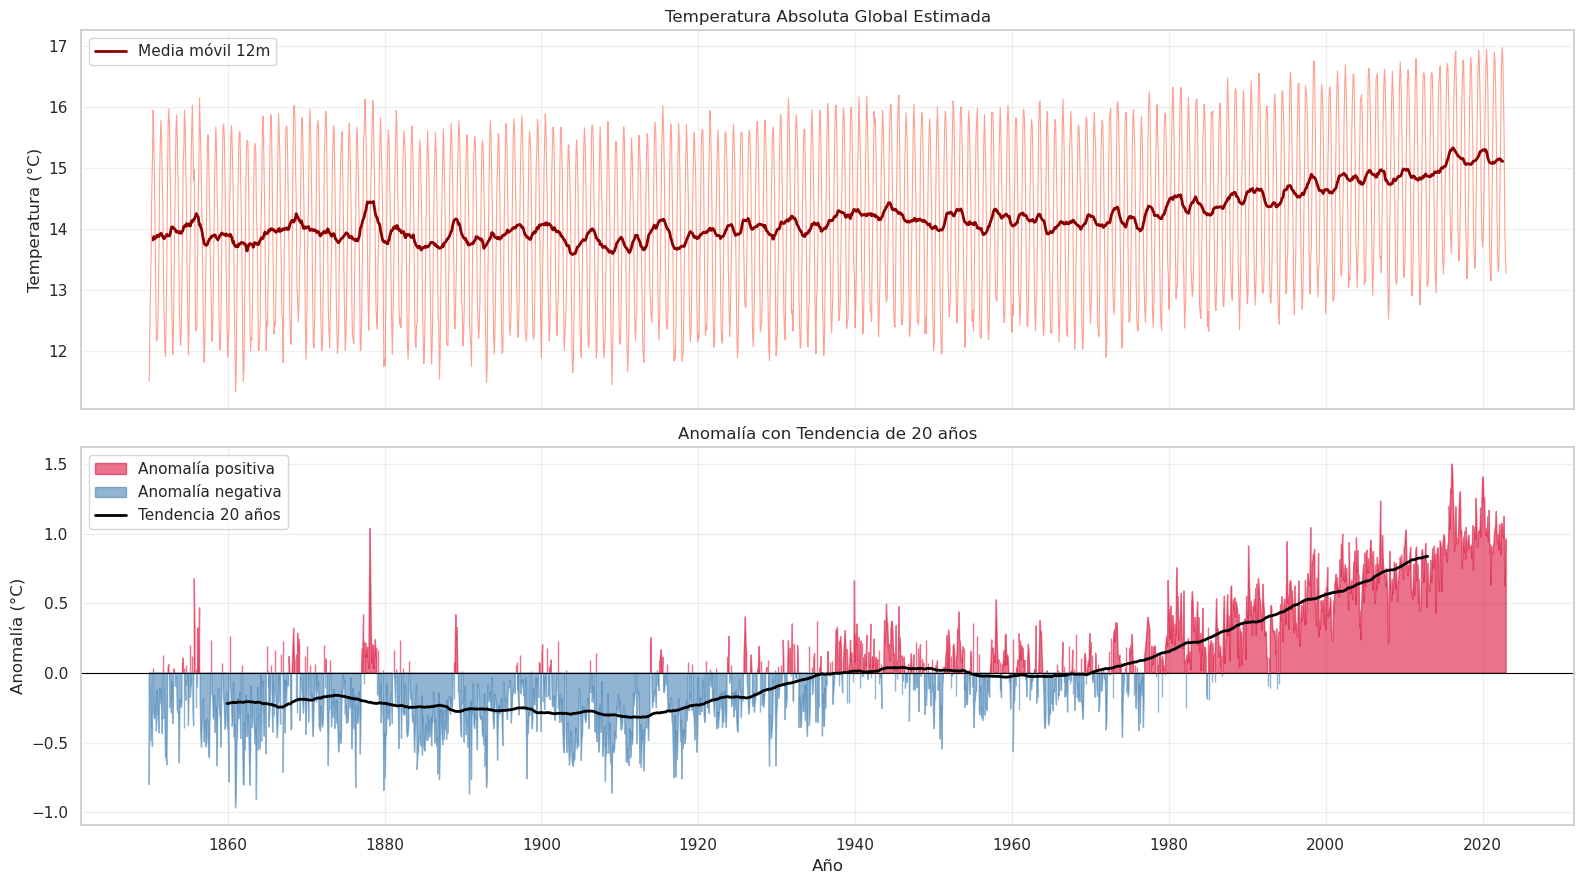

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Temperatura absoluta
axes[0].plot(df.index, df['temp_abs'],
             color='tomato', linewidth=0.8, alpha=0.6)
# Media móvil de 12 meses calculada manualmente
rolling_12 = df['temp_abs'].rolling(window=12, center=True).mean()
axes[0].plot(df.index, rolling_12, color='darkred', linewidth=2, label='Media móvil 12m')
axes[0].set_title('Temperatura Absoluta Global Estimada')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()

# Anomalía con tendencia
axes[1].fill_between(df.index, df['anomaly_monthly'], 0,
                     where=(df['anomaly_monthly'] >= 0),
                     alpha=0.6, color='crimson', label='Anomalía positiva')
axes[1].fill_between(df.index, df['anomaly_monthly'], 0,
                     where=(df['anomaly_monthly'] < 0),
                     alpha=0.6, color='steelblue', label='Anomalía negativa')
axes[1].plot(df.index, df['anomaly_20yr'], color='black', linewidth=2, label='Tendencia 20 años')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Anomalía con Tendencia de 20 años')
axes[1].set_ylabel('Anomalía (°C)')
axes[1].set_xlabel('Año')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Correlaciones

La matriz de correlación de Pearson mide la relación lineal entre pares de variables. Valores cercanos a 1 o -1 indican correlación alta; cercanos a 0 indican sin correlación lineal.

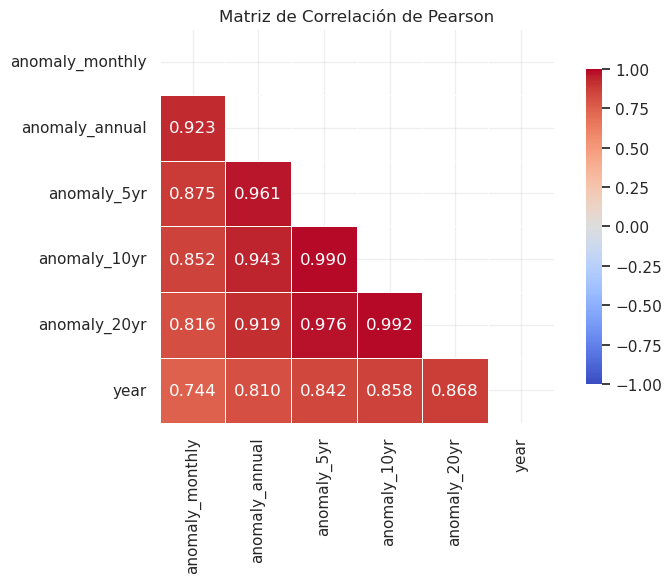

In [27]:
cols_corr = ['anomaly_monthly', 'anomaly_annual', 'anomaly_5yr',
             'anomaly_10yr', 'anomaly_20yr', 'year']

corr_matrix = df[cols_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Matriz de Correlación de Pearson')
plt.tight_layout()
plt.show()

In [28]:
# Correlación de la anomalía mensual con el año (tendencia temporal)
corr_año = df['anomaly_monthly'].corr(df['year'])
print(f'Correlación anomalía mensual vs año: {corr_año:.4f}')
print('→ Correlación positiva indica calentamiento progresivo a lo largo del tiempo.')

Correlación anomalía mensual vs año: 0.7438
→ Correlación positiva indica calentamiento progresivo a lo largo del tiempo.


---
## 7. Análisis de Tendencia con Regresión Lineal

Ajustamos una recta de regresión sobre los datos anuales para cuantificar la tasa de calentamiento.

Pendiente:    0.00630 °C/año  =  0.0630 °C/década
Intercepto:   -12.1569
R²:           0.6654


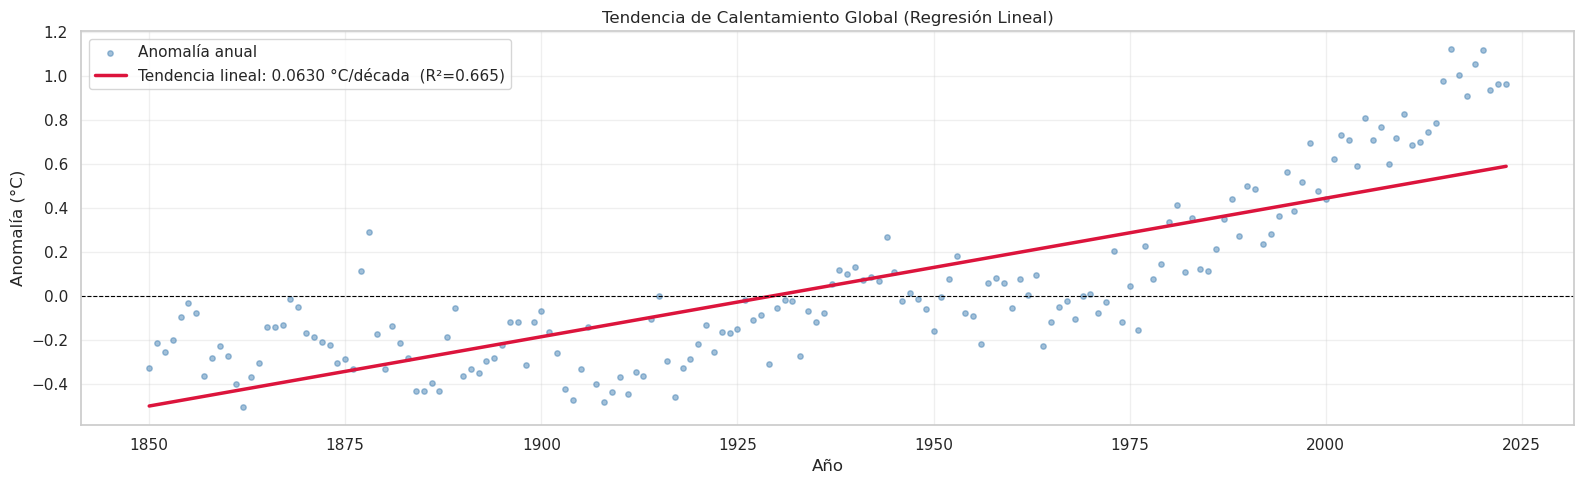

In [29]:
# Datos anuales válidos
df_anual = df.groupby('year')['anomaly_monthly'].mean().dropna()

x = df_anual.index.values
y = df_anual.values

# Regresión lineal con NumPy (mínimos cuadrados)
coefs = np.polyfit(x, y, deg=1)  # [pendiente, intercepto]
pendiente, intercepto = coefs
recta = np.poly1d(coefs)

# R² 
y_pred = recta(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f'Pendiente:    {pendiente:.5f} °C/año  =  {pendiente*10:.4f} °C/década')
print(f'Intercepto:   {intercepto:.4f}')
print(f'R²:           {r2:.4f}')

fig, ax = plt.subplots(figsize=(16, 5))
ax.scatter(x, y, s=15, alpha=0.5, color='steelblue', label='Anomalía anual')
ax.plot(x, recta(x), color='crimson', linewidth=2.5,
        label=f'Tendencia lineal: {pendiente*10:.4f} °C/década  (R²={r2:.3f})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Tendencia de Calentamiento Global (Regresión Lineal)')
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía (°C)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Conclusiones del EDA

### Hallazgos principales:

1. **Calentamiento progresivo**: La anomalía promedio pasó de **≈ −0.3°C** en el siglo XIX a **≈ +1.0°C** en la década de 2010–2020, un cambio total de ~1.3°C en 170 años.

2. **Aceleración reciente**: La tasa de calentamiento es de aproximadamente **0.07–0.09 °C por década** en el período completo (1850–2023), pero se ha acelerado significativamente desde ~1970.

3. **Valores faltantes**: Las medias móviles de largo plazo (5, 10, 20 años) tienen NaN en los extremos del dataset porque requieren datos futuros/pasados para el cálculo centrado. La anomalía mensual es la columna más completa.

4. **Distribución**: La distribución de anomalías mensuales es aproximadamente normal con ligera asimetría positiva. El período post-1980 tiene su distribución desplazada claramente hacia valores positivos.

5. **No hay estacionalidad fuerte en las anomalías**: Los boxplots por mes no muestran patrones sistemáticos grandes, lo que confirma que las anomalías están relativamente bien homogeneizadas estacionalmente.

6. **Outliers**: Los valores atípicos se concentran principalmente en el período reciente (post-2000), correspondiendo a años récord de calor.

### Próximos pasos para modelado:

- Crear features de lag temporal (anomalía del mes anterior, del año anterior)
- Codificar el mes como feature cíclica (sin/cos)
- Normalizar/estandarizar las variables
- Separar en conjuntos de entrenamiento y prueba respetando el orden temporal
- Explorar modelos de series de tiempo: ARIMA, Prophet, LSTM o regresión con features temporales